# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
LABEL_MAP = {
    "with israel":  0,
    "with palestine":  1,
    "neutral":  2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'with israel': 0, 'with palestine': 1, 'neutral': 2}
Number of labels: 3


In [4]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving r_worldnews.csv to r_worldnews (1).csv
Uploaded: r_worldnews (1).csv


In [5]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)
print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['label', 'text']
Total examples: 600

Label distribution:
label
neutral           200
with israel       200
with palestine    200
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [7]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 420 examples
Validation: 90 examples
Test: 90 examples

Train label distribution:
label
neutral           140
with israel       140
with palestine    140
Name: count, dtype: int64

Test label distribution:
label
with palestine    30
with israel       30
neutral           30
Name: count, dtype: int64


In [8]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [9]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=10,  # Changed from 3 to 10
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.05,  # Changed from 0.01 to 0.05
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.099511,1.086413,0.366667
2,1.015778,0.996001,0.533333
3,0.831639,0.894009,0.622222
4,0.708101,0.916988,0.566667
5,0.567796,0.932684,0.577778
6,0.382127,0.929690,0.600000
7,0.285874,1.005879,0.555556
8,0.208021,1.062627,0.533333
9,0.130769,1.110723,0.588889
10,0.089250,1.130886,0.611111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [12]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.678

Per-class metrics (fine-tuned model):
                precision    recall  f1-score   support

   with israel       0.67      1.00      0.80        30
with palestine       0.64      0.47      0.54        30
       neutral       0.74      0.57      0.64        30

      accuracy                           0.68        90
     macro avg       0.68      0.68      0.66        90
  weighted avg       0.68      0.68      0.66        90



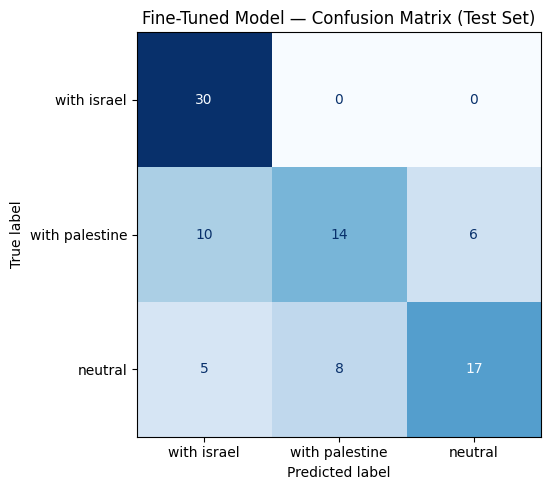

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [13]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [14]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 29 / 90

--- #1 ---
Text:      Literally had an irl friend say "Who cares about Israelis" when I cited the Oct 7th massacre. We see eye to eye on 99% of every political and world issue, but they fiercely said it was AI-generated Is...
True:      neutral
Predicted: with israel  (confidence: 0.69)

--- #2 ---
Text:      I am a Muslim, I am a father, This is fucking disgusting and brought tears to my eyes. 
If you can do this to a child let alone another human you are so beyond evil. 
I don't know what to make of this...
True:      with palestine
Predicted: with israel  (confidence: 0.41)

--- #3 ---
Text:      I'll just add, Netenyahu is NOT Israel.
You can be pro an independent, free Palestine, a strong, independent Israel, *and* anti-Netenyahu, anti-Hamas, anti-Iranian Ayatollahs and anti-Hezbollah.
We sh...
True:      neutral
Predicted: with palestine  (confidence: 0.49)

--- #4 ---
Text:      Here's what Egypt is really warning about for people who don't understand

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [15]:
from groq import Groq
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [16]:
SYSTEM_PROMPT = """You are classifying posts and comments from a subreddit discussing the Israel-Palestine conflict. Assign each post to exactly one of the following categories:

LABEL: with israel
DEFINITION: The post expresses support for or alignment with Israel's position. The commenter presents arguments in favor of Israeli policies, actions, or existence, often with supporting context or counter-arguments to opposing views.
EXAMPLE: "The IDF on Friday denied allegations by Hamas that Israeli forces had fired on civilians awaiting aid in Gaza City, saying that soldiers had not used their weapons at any stage of the incident and pointed to Palestinian gunmen as the cause of the casualties. The incident took place late on Thursday after the military allowed 31 aid trucks to pass into the Gaza Strip heading toward Gaza City in the territory's north. According to unverified Palestinian reports, at least 40 people waiting for the convoy have been killed in the incident."

LABEL: with palestine
DEFINITION: The post expresses support for or alignment with Palestine's position. The commenter advocates for Palestinian rights, criticizes Israeli policies, or presents historical and political arguments favoring Palestinian interests.
EXAMPLE: "It's idiotic for Hamas to do this when Netanyahu and a hard right coalition are in power. For one thing it's going to result in a full force counter attack that will kill hundreds of not thousands of Palestinians. For another thing it will likely result in a surge in support for Netanyahu who will use it as mandate to further push the policies that harm Palestinians."

LABEL: neutral
DEFINITION: The post takes a balanced or non-committal stance on the Israel-Palestine conflict. The comment acknowledges both sides, expresses uncertainty, calls for nuance, or focuses on humanitarian concerns without strongly endorsing either side's political position.
EXAMPLE: "Reminder: Your beef isn't with Israel or Palestine, it's with a small handful of officials in charge who have done the unforgivable for power at the cost of lives on both sides. Sarah the Jewish girl working at the Tel Aviv Gap Store and Ahmed the Shia Butcher are not the reason things suck in the middle east right now."

VALID LABELS (respond with exactly one):
with israel
with palestine
neutral

INSTRUCTIONS:
- Analyze the post carefully, considering the underlying position, not just surface claims
- For sarcasm or satire, identify the true position being expressed
- Choose from the four valid labels only and respond with ONLY the label name, nothing else
- Do not explain your reasoning
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 2605 characters


In [17]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 90 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/90 complete...
  20/90 complete...
  30/90 complete...
  40/90 complete...
  50/90 complete...
  60/90 complete...
  70/90 complete...
  80/90 complete...
  90/90 complete...


In [18]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.833  (evaluated on 90/90 parseable responses)

Per-class metrics (baseline):
                precision    recall  f1-score   support

   with israel       0.79      0.90      0.84        30
with palestine       0.92      0.80      0.86        30
       neutral       0.80      0.80      0.80        30

      accuracy                           0.83        90
     macro avg       0.84      0.83      0.83        90
  weighted avg       0.84      0.83      0.83        90



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [19]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.833
Fine-tuned DistilBERT                  0.678
---------------------------------------------

Fine-tuning regression: 0.156

Use these numbers in your README evaluation report.


In [20]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
